Image Pattern Visualization using t-SNE

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving image_pattern_tsne_digits_dataset.csv to image_pattern_tsne_digits_dataset.csv


In [ ]:
df = pd.read_csv("image_pattern_tsne_digits_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1797, 65)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,digit_label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
X = df.drop("digit_label", axis=1)
y = df["digit_label"]

print("Image features:", X.shape)
print("Labels:", y.shape)

Image features: (1797, 64)
Labels: (1797,)


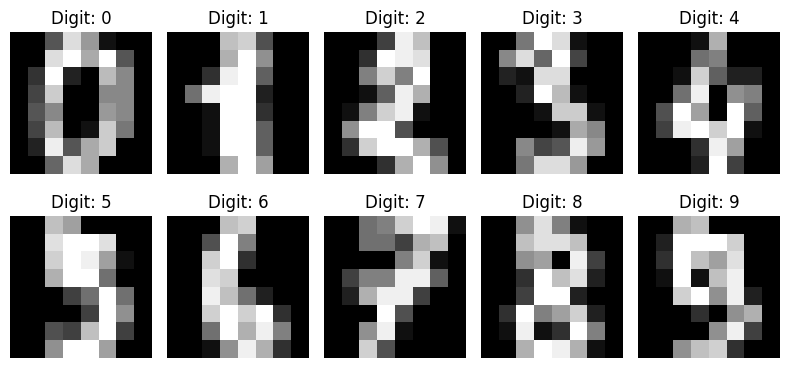

In [ ]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X.iloc[i].values.reshape(8, 8), cmap="gray")
    plt.title(f"Digit: {y.iloc[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="random"
)

X_tsne = tsne.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", X_tsne.shape)

Original shape: (1797, 64)
Reduced shape: (1797, 2)


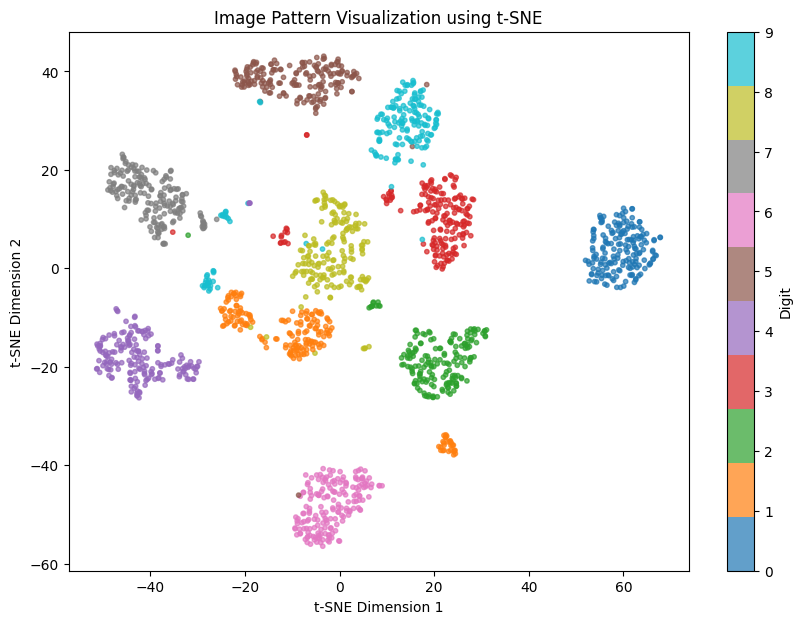

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.title("Image Pattern Visualization using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(label="Digit")

plt.show()

In [ ]:
print("t-SNE successfully reduced 64-dimensional image data to 2 dimensions.")
print("The visualization shows clusters representing similar handwritten digit patterns.")

t-SNE successfully reduced 64-dimensional image data to 2 dimensions.
The visualization shows clusters representing similar handwritten digit patterns.


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


# -----------------------------
# PAGE SETUP
# -----------------------------

st.set_page_config(
    page_title="t-SNE Image Pattern Visualization",
    page_icon="🖼️",
    layout="wide"
)

st.title("Image Pattern Visualization using t-SNE")

st.write(
    "This project uses t-SNE to visualize high-dimensional "
    "image data and identify hidden patterns."
)


# -----------------------------
# LOAD DATASET
# -----------------------------

digits = load_digits()

X = digits.data
y = digits.target


# -----------------------------
# SIDEBAR
# -----------------------------

st.sidebar.title("Model Settings")

perplexity = st.sidebar.slider(
    "t-SNE Perplexity",
    5,
    50,
    30
)

neighbors = st.sidebar.slider(
    "KNN Neighbors",
    1,
    15,
    5
)


# -----------------------------
# DATASET INFORMATION
# -----------------------------

st.header("Dataset Information")

col1, col2, col3 = st.columns(3)

col1.metric("Total Images", X.shape[0])
col2.metric("Image Features", X.shape[1])
col3.metric("Number of Classes", len(np.unique(y)))


# -----------------------------
# SAMPLE IMAGES
# -----------------------------

st.header("Sample Images")

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):

    ax.imshow(digits.images[i], cmap="gray")

    ax.set_title(f"Digit: {y[i]}")

    ax.axis("off")

plt.tight_layout()

st.pyplot(fig)


# -----------------------------
# t-SNE
# -----------------------------

st.header("t-SNE Visualization")

with st.spinner("Applying t-SNE..."):

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42
    )

    X_tsne = tsne.fit_transform(X)


fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=15
)

ax.set_title(
    "Image Pattern Visualization using t-SNE"
)

ax.set_xlabel("t-SNE Dimension 1")

ax.set_ylabel("t-SNE Dimension 2")

plt.colorbar(
    scatter,
    ax=ax,
    label="Digit Class"
)

st.pyplot(fig)


# -----------------------------
# KNN CLASSIFICATION
# -----------------------------

st.header("KNN Classification")

X_train, X_test, y_train, y_test = train_test_split(
    X_tsne,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

knn = KNeighborsClassifier(
    n_neighbors=neighbors
)

knn.fit(X_train, y_train)

pred = knn.predict(X_test)

accuracy = accuracy_score(
    y_test,
    pred
)


st.metric(
    "KNN Accuracy",
    f"{accuracy * 100:.2f}%"
)


# -----------------------------
# CONFUSION MATRIX
# -----------------------------

st.header("Confusion Matrix")

cm = confusion_matrix(
    y_test,
    pred
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.imshow(
    cm,
    cmap="Blues"
)

ax.set_title(
    "KNN Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "Actual Label"
)

ax.set_xticks(range(10))
ax.set_yticks(range(10))

st.pyplot(fig)


# -----------------------------
# CONCLUSION
# -----------------------------

st.header("Project Conclusion")

st.write(
    "t-SNE reduces high-dimensional image features "
    "into two dimensions, making hidden patterns and "
    "similarities easier to visualize. KNN is then "
    "used to classify the reduced image data."
)

st.success(
    "Image Pattern Visualization using t-SNE completed successfully!"
)

Overwriting app.py


In [ ]:
%%writefile requirements.txt

streamlit
numpy
matplotlib
scikit-learn

Writing requirements.txt


In [ ]:
!ls

app.py	requirements.txt  sample_data


In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 40.6 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!pkill -f streamlit

In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 5s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!lt --port 8501

your url is: https://whole-files-carry.loca.lt
^C


In [ ]:
!pkill -f streamlit
!pkill -f lt

In [ ]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [ ]:
!pkill -f streamlit
!pkill -f lt

In [ ]:
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

In [ ]:
from google.colab import output
output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [30]:
!cat /content/logs.txt



2026-10-07 09:05:11.326 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.61.14:8501



Dataset shape: (1797, 64)
Number of classes: 10


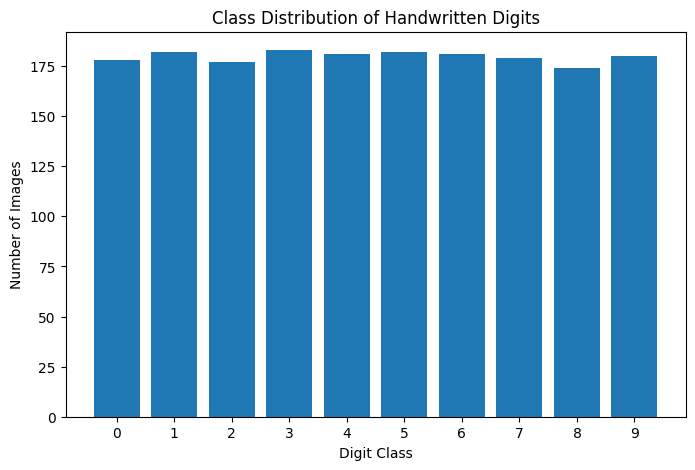

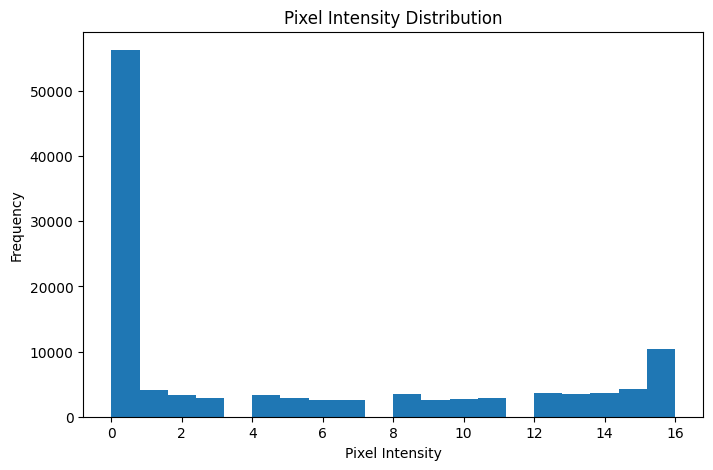

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Load dataset
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))


# -----------------------------
# 1. CLASS DISTRIBUTION
# -----------------------------

classes, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)

plt.title("Class Distribution of Handwritten Digits")
plt.xlabel("Digit Class")
plt.ylabel("Number of Images")
plt.xticks(classes)

plt.show()


# -----------------------------
# 2. PIXEL INTENSITY DISTRIBUTION
# -----------------------------

plt.figure(figsize=(8, 5))

plt.hist(X.flatten(), bins=20)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

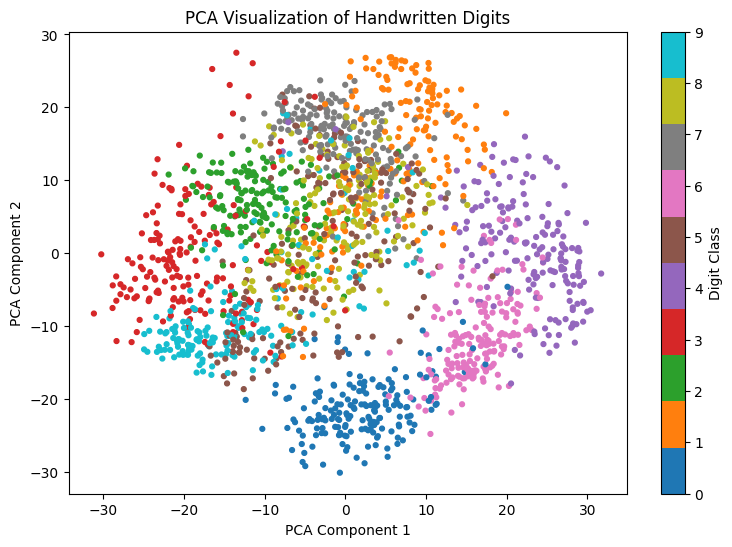

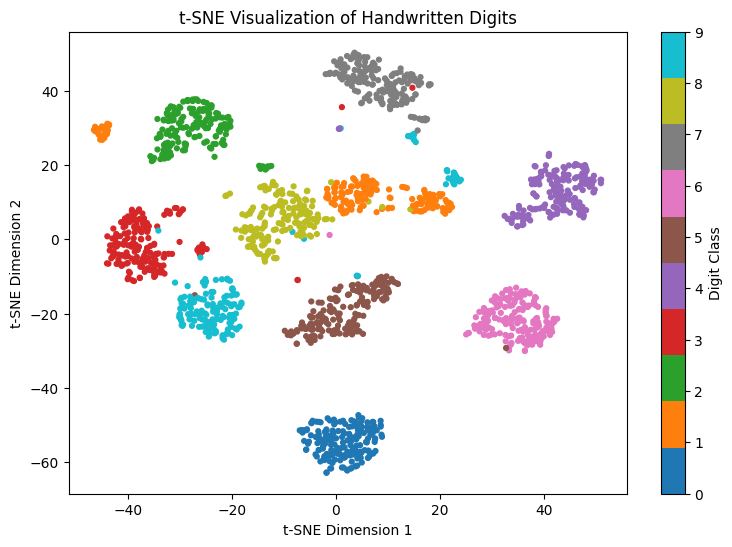

In [34]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# PCA: reduce 64 dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# t-SNE: reduce 64 dimensions to 2
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

# -----------------------------
# PCA VISUALIZATION
# -----------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="tab10",
    s=12
)

plt.title("PCA Visualization of Handwritten Digits")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Digit Class")

plt.show()


# -----------------------------
# t-SNE VISUALIZATION
# -----------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=12
)

plt.title("t-SNE Visualization of Handwritten Digits")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(label="Digit Class")

plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1 Score
0                  KNN  0.983333   0.983886  0.983333  0.983319
1  Logistic Regression  0.908333   0.923711  0.908333  0.908588


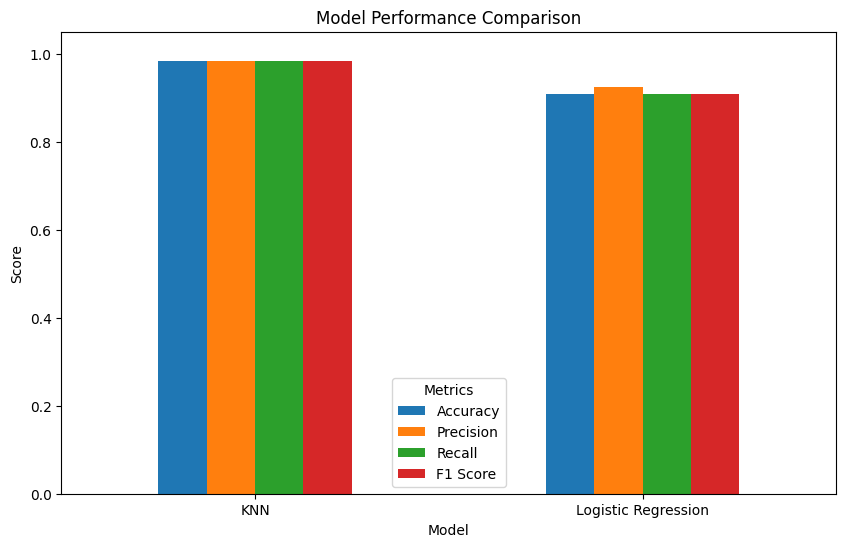


KNN Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.94      0.91      0.93        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import pandas as pd
import matplotlib.pyplot as plt

# Split t-SNE data
X_train, X_test, y_train, y_test = train_test_split(
    X_tsne,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# MODEL 1: KNN
# -----------------------------

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)


# -----------------------------
# MODEL 2: LOGISTIC REGRESSION
# -----------------------------

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)


# -----------------------------
# CALCULATE METRICS
# -----------------------------

models = {
    "KNN": knn_pred,
    "Logistic Regression": lr_pred
}

results = []

for name, prediction in models.items():

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(
        y_test, prediction, average="weighted"
    )
    recall = recall_score(
        y_test, prediction, average="weighted"
    )
    f1 = f1_score(
        y_test, prediction, average="weighted"
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])


# -----------------------------
# RESULTS TABLE
# -----------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(results_df)


# -----------------------------
# MODEL COMPARISON BAR CHART
# -----------------------------

results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.legend(
    title="Metrics"
)

plt.show()


# -----------------------------
# KNN CLASSIFICATION REPORT
# -----------------------------

print("\nKNN Classification Report:\n")

print(
    classification_report(
        y_test,
        knn_pred
    )
)

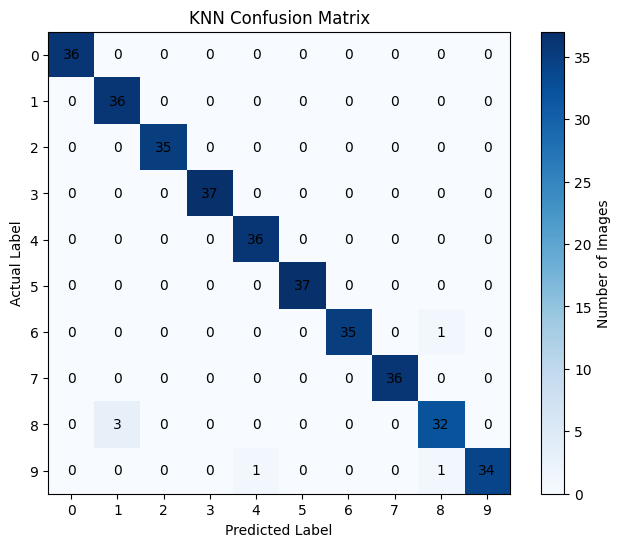

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(8, 6))

plt.imshow(cm, cmap="Blues")

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(range(10))
plt.yticks(range(10))

# Add numbers inside cells
for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of Images")

plt.show()

In [47]:
%%writefile app.py

import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# --------------------------------------------------
# PAGE SETTINGS
# --------------------------------------------------

st.set_page_config(
    page_title="Image Pattern Visualization using t-SNE",
    page_icon="🖼️",
    layout="wide"
)

st.title("Image Pattern Visualization using t-SNE")

st.write(
    "This project uses t-SNE to visualize high-dimensional "
    "image data and identify hidden patterns."
)

# --------------------------------------------------
# LOAD DATASET
# --------------------------------------------------

digits = load_digits()

X = digits.data
y = digits.target

# --------------------------------------------------
# SIDEBAR SETTINGS
# --------------------------------------------------

st.sidebar.title("Model Settings")

perplexity = st.sidebar.slider(
    "t-SNE Perplexity",
    5,
    50,
    30
)

neighbors = st.sidebar.slider(
    "KNN Neighbors",
    1,
    15,
    5
)

# --------------------------------------------------
# DATASET INFORMATION
# --------------------------------------------------

st.header("Dataset Information")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Total Images",
    X.shape[0]
)

col2.metric(
    "Image Features",
    X.shape[1]
)

col3.metric(
    "Number of Classes",
    len(np.unique(y))
)

# --------------------------------------------------
# CLASS DISTRIBUTION
# --------------------------------------------------

st.header("Class Distribution")

classes, counts = np.unique(y, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(classes, counts)

ax.set_title("Class Distribution of Handwritten Digits")
ax.set_xlabel("Digit Class")
ax.set_ylabel("Number of Images")
ax.set_xticks(classes)

st.pyplot(fig)

plt.close(fig)

# --------------------------------------------------
# PIXEL INTENSITY DISTRIBUTION
# --------------------------------------------------

st.header("Pixel Intensity Distribution")

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    X.flatten(),
    bins=20
)

ax.set_title("Pixel Intensity Distribution")
ax.set_xlabel("Pixel Intensity")
ax.set_ylabel("Frequency")

st.pyplot(fig)

plt.close(fig)

# --------------------------------------------------
# SAMPLE IMAGES
# --------------------------------------------------

st.header("Sample Images")

fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 4)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        digits.images[i],
        cmap="gray"
    )

    ax.set_title(
        f"Digit: {y[i]}"
    )

    ax.axis("off")

plt.tight_layout()

st.pyplot(fig)

plt.close(fig)

# --------------------------------------------------
# PCA VISUALIZATION
# --------------------------------------------------

st.header("PCA Visualization")

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="tab10",
    s=12
)

ax.set_title(
    "PCA Visualization of Handwritten Digits"
)

ax.set_xlabel(
    "PCA Component 1"
)

ax.set_ylabel(
    "PCA Component 2"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Digit Class"
)

st.pyplot(fig)

plt.close(fig)

# --------------------------------------------------
# t-SNE VISUALIZATION
# --------------------------------------------------

st.header("t-SNE Visualization")

with st.spinner("Applying t-SNE..."):

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42
    )

    X_tsne = tsne.fit_transform(X)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

scatter = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=12
)

ax.set_title(
    "t-SNE Visualization of Handwritten Digits"
)

ax.set_xlabel(
    "t-SNE Dimension 1"
)

ax.set_ylabel(
    "t-SNE Dimension 2"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Digit Class"
)

st.pyplot(fig)

plt.close(fig)

# --------------------------------------------------
# TRAIN TEST SPLIT
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_tsne,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# KNN MODEL
# --------------------------------------------------

knn = KNeighborsClassifier(
    n_neighbors=neighbors
)

knn.fit(
    X_train,
    y_train
)

knn_pred = knn.predict(
    X_test
)

# --------------------------------------------------
# LOGISTIC REGRESSION MODEL
# --------------------------------------------------

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

# --------------------------------------------------
# METRICS FUNCTION
# --------------------------------------------------

def calculate_metrics(y_true, prediction):

    return [
        accuracy_score(
            y_true,
            prediction
        ),

        precision_score(
            y_true,
            prediction,
            average="weighted"
        ),

        recall_score(
            y_true,
            prediction,
            average="weighted"
        ),

        f1_score(
            y_true,
            prediction,
            average="weighted"
        )
    ]


# --------------------------------------------------
# CALCULATE MODEL METRICS
# --------------------------------------------------

knn_metrics = calculate_metrics(
    y_test,
    knn_pred
)

lr_metrics = calculate_metrics(
    y_test,
    lr_pred
)

# --------------------------------------------------
# MODEL PERFORMANCE TABLE
# --------------------------------------------------

st.header("Model Performance")

results_df = pd.DataFrame(
    [
        ["KNN"] + knn_metrics,
        ["Logistic Regression"] + lr_metrics
    ],

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

st.dataframe(
    results_df.style.format(
        {
            "Accuracy": "{:.2%}",
            "Precision": "{:.2%}",
            "Recall": "{:.2%}",
            "F1 Score": "{:.2%}"
        }
    )
)

# --------------------------------------------------
# MODEL PERFORMANCE COMPARISON
# --------------------------------------------------

st.header(
    "Model Performance Comparison"
)

plot_df = results_df.set_index(
    "Model"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

plot_df.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel(
    "Score"
)

ax.set_xlabel(
    "Model"
)

ax.set_ylim(
    0,
    1.05
)

plt.xticks(
    rotation=0
)

st.pyplot(fig)

plt.close(fig)

# --------------------------------------------------
# KNN CONFUSION MATRIX
# --------------------------------------------------

st.header(
    "KNN Confusion Matrix"
)

cm = confusion_matrix(
    y_test,
    knn_pred
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

# IMPORTANT:
# Save the image returned by imshow
# so the colorbar knows what to represent.

im = ax.imshow(
    cm,
    cmap="Blues"
)

ax.set_title(
    "KNN Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Label"
)

ax.set_ylabel(
    "Actual Label"
)

ax.set_xticks(
    range(10)
)

ax.set_yticks(
    range(10)
)

# Display values inside the matrix

for i in range(10):

    for j in range(10):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

# CORRECT COLORBAR CODE

fig.colorbar(
    im,
    ax=ax,
    label="Number of Images"
)

st.pyplot(fig)

plt.close(fig)

# --------------------------------------------------
# FINAL RESULT
# --------------------------------------------------

st.header(
    "Final Result"
)

st.metric(
    "KNN Accuracy",
    f"{knn_metrics[0] * 100:.2f}%"
)

if knn_metrics[0] > lr_metrics[0]:

    st.success(
        "KNN performs better than Logistic Regression "
        "on the t-SNE reduced image data."
    )

else:

    st.success(
        "Logistic Regression performs better than KNN "
        "on the t-SNE reduced image data."
    )

# --------------------------------------------------
# PROJECT CONCLUSION
# --------------------------------------------------

st.header(
    "Project Conclusion"
)

st.write(
    "The digits dataset contains 1797 images with 64 "
    "features per image. PCA and t-SNE were used to "
    "reduce the high-dimensional data into two dimensions. "
    "The t-SNE visualization produces clearer clusters "
    "of handwritten digit classes. KNN and Logistic "
    "Regression were evaluated on the reduced data. "
    "KNN achieved higher classification performance, "
    "demonstrating that the t-SNE representation preserves "
    "useful patterns for classification."
)

st.success(
    "Image Pattern Visualization using t-SNE completed successfully!"
)

Overwriting app.py


In [38]:
!ls -lh app.py

-rw-r--r-- 1 root root 7.3K Oct  7 09:23 app.py


In [39]:
!zip -r tsne_project.zip app.py requirements.txt

  adding: app.py (deflated 69%)
  adding: requirements.txt (stored 0%)


In [40]:
from google.colab import files
files.download("tsne_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
!pkill -f streamlit

In [49]:
import subprocess

process = subprocess.Popen(
    [
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.address", "0.0.0.0",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false"
    ],
    stdout=open("/content/logs.txt", "w"),
    stderr=subprocess.STDOUT
)

print("Streamlit dashboard started successfully")

Streamlit dashboard started successfully


In [50]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [52]:
!git clone https://github.com/surajborde/Image-Pattern-Visualization-tSNE.git

Cloning into 'Image-Pattern-Visualization-tSNE'...


In [53]:
!cp app.py requirements.txt Image-Pattern-Visualization-tSNE/

In [54]:
!ls -lh Image-Pattern-Visualization-tSNE/

total 16K
-rw-r--r-- 1 root root 9.1K Oct  7 09:43 app.py
-rw-r--r-- 1 root root   41 Oct  7 09:43 requirements.txt
